In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0315_dps_test.fits')

In [3]:
stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
stellar_df.head()

,TARGETID,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056154,DEV,4.000000,1.577094,145.330002,44.629128
1,39627739380056197,REX,1.000000,0.969577,78.970001,0.000000
2,39627739380056420,SER,0.722487,2.256895,2.770000,79.009950
3,39627739380056564,REX,1.000000,1.275339,59.770000,0.000000
4,39627739380056768,EXP,1.000000,3.253861,72.139999,78.399880


In [4]:
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_1comp,BPT_2compL,BPT_2compR,dp_count,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429682,...,256,256,256,2,512,REX,1.000000,1.275339,59.770000,0.000000
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,113.683365,-61.165855,41.490192,69.213898,...,256,256,256,1,512,REX,1.000000,0.781829,110.419998,0.000000
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.310776,-28.034325,30.202028,51.832150,...,256,256,256,3,512,SER,1.144523,3.020720,86.650002,71.269295
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,73.980766,-94.167976,57.098171,51.152435,...,256,256,256,2,512,SER,2.648419,1.265829,124.010002,47.433067
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.747307,-73.973824,38.576229,50.498489,...,1,1,1,5,2,SER,1.779606,0.794439,100.040001,50.672260


In [5]:
print(len(dps_df))

25671


In [6]:
model_1comp_dps = model_1comp_dps[dps_df.index]
left_2comp_dps = left_2comp_dps[dps_df.index]
right_2comp_dps = right_2comp_dps[dps_df.index]

In [7]:
delta_dv = dps_df['dv_r'] - dps_df['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['sigma_l']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


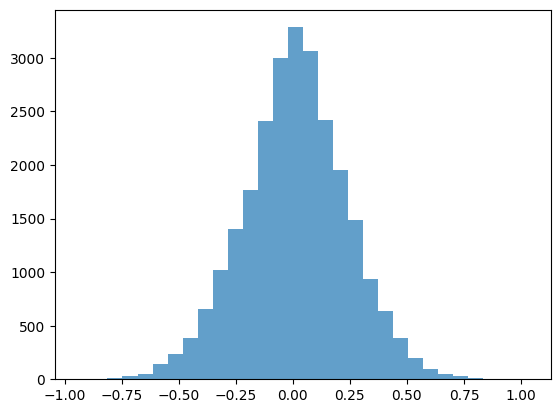

In [8]:
plt.hist(np.log10(dps_df['width_ratio']), bins=30, alpha=0.7, color='C0')
plt.show()

In [9]:
print(len(dps_df[np.log10(dps_df['width_ratio'])<0]))
print(len(dps_df[np.log10(dps_df['width_ratio'])>0]))

12183
13488


In [10]:
dps_df['flux_ratio'] = 0
for i in range(len(dps_df)):
    lam = desi_wavelength/(1+dps_df['Z'][i])
    left_shift = dps_df['dv_l'][i] / c * Halpha_rest[0]
    right_shift = dps_df['dv_r'][i] / c * Halpha_rest[0]

    left_flux = np.max(left_2comp_dps[i][(lam>(Halpha_rest[0]+left_shift-2)) & (lam<(Halpha_rest[0]+left_shift+2))])
    right_flux = np.max(right_2comp_dps[i][(lam>(Halpha_rest[0]+right_shift-2)) & (lam<(Halpha_rest[0]+right_shift+2))])

    if ((right_flux < 1) and (left_flux < 1)) or (dps_df['Halpha_dp'].iloc[i] is False):
        dps_df['flux_ratio'].iloc[i] = np.nan
    else:
        dps_df['flux_ratio'].iloc[i] = left_flux / right_flux


# dps_df['flux_ratio'] = 0
# for i in range(len(dps_df)):
#     lam = desi_wavelength/(1+dps_df['Z'][i])
#     left_shift = dps_df['dv_l'][i] / c * OIII_rest[1]
#     right_shift = dps_df['dv_r'][i] / c * OIII_rest[1]

#     left_flux = np.max(left_2comp_dps[i][(lam>(OIII_rest[1]+left_shift-2)) & (lam<(OIII_rest[1]+left_shift+2))])
#     right_flux = np.max(right_2comp_dps[i][(lam>(OIII_rest[1]+right_shift-2)) & (lam<(OIII_rest[1]+right_shift+2))])

#     if ((right_flux < 1) and (left_flux < 1)) or (dps_df['OIII5007_dp'].iloc[i] is False):
#         dps_df['flux_ratio'].iloc[i] = np.nan
#     else:
#         dps_df['flux_ratio'].iloc[i] = left_flux / right_flux



/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_29310/176573913.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dps_df['flux_ratio'].iloc[i] = left_flux / right_flux
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_

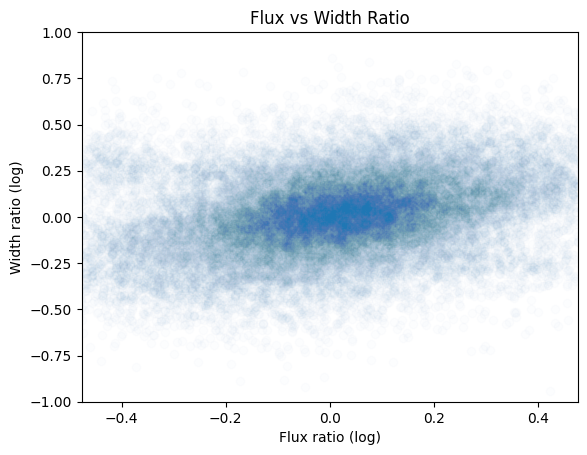

In [11]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(dps_df['width_ratio'])), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(dps_df['width_ratio'])), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.ylim(bottom=np.log10(1/10), top=np.log10(10))
plt.title('Flux vs Width Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/flux_width_ratio.png')
plt.show()

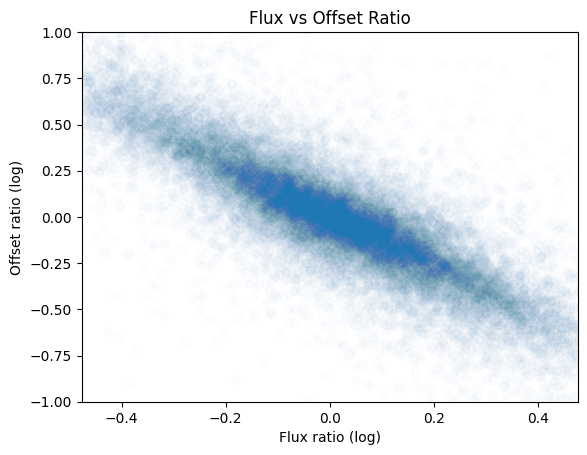

In [12]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.ylim(bottom=-1, top=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.title('Flux vs Offset Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Offset ratio (log)')
plt.savefig('./figures/Feb6/flux_offset_ratio.png')
plt.show()

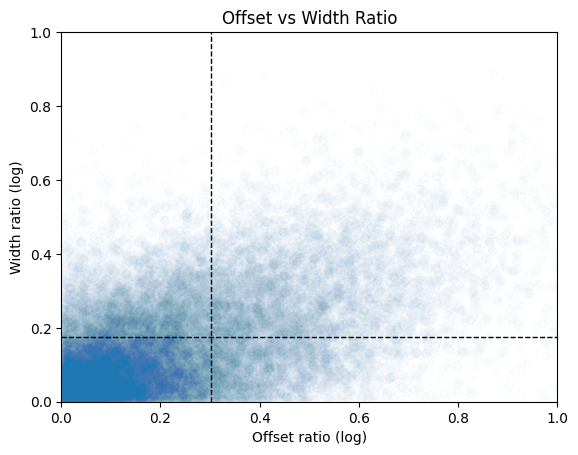

In [13]:
plt.scatter(np.abs(np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), np.abs(np.log10(dps_df['width_ratio'])), alpha=0.01)
# plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.axvline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=0, right=1)
plt.ylim(bottom=0, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/offset_width_ratio_abs.png')
plt.show()

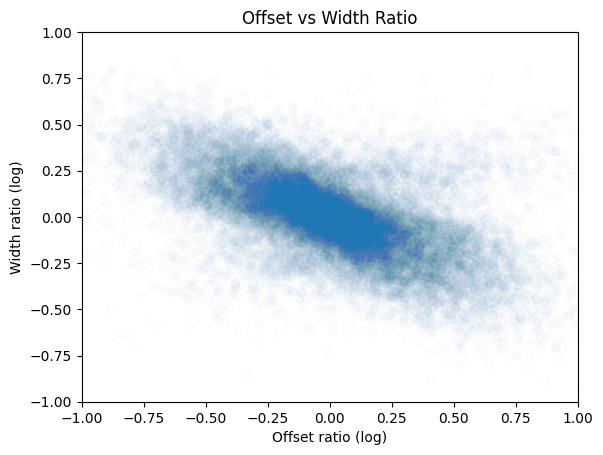

In [14]:
plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.xlim(left=-1, right=1)
plt.ylim(bottom=-1, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.show()

In [15]:
print(len(dps_df[np.log10(-dps_df['dv_l']/(dps_df['dv_r']))<0]))
print(len(dps_df[np.log10(-dps_df['dv_l']/(dps_df['dv_r']))>0]))

13076
12595


In [16]:
def extract_symmetry(df, flux=None, width=None, offset=None):
    combine_crit = np.ones(len(df), dtype=bool)
    
    if flux is True:
        # flux_crit = np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
        combine_crit &= np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
    elif flux is False:
        combine_crit &=  np.abs(np.log10(df['flux_ratio']))>=np.log10(1.3)
    elif flux is None:
        pass

    if width is True:
        combine_crit &= np.abs(np.log10(df['width_ratio']))<np.log10(1.5)
    elif width is False:
        combine_crit &= np.abs(np.log10(df['width_ratio']))>=np.log10(1.5)
    elif width is None:
        pass

    if offset is True:
        combine_crit &= np.abs(np.log10(-df['dv_l']/(df['dv_r'])))<np.log10(2)
    elif offset is False:
        combine_crit &= np.abs(np.log10(-df['dv_l']/(df['dv_r'])))>=np.log10(2)
    elif offset is None:
        pass

    return df[combine_crit]


In [17]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [18]:
dps_df['BPT_class_str'] = dps_df['BPT_2comp'].map(classification_map)

In [19]:
sWsO = extract_symmetry(dps_df, flux=None, width=True, offset=True)
sWsO.head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429682,...,512,REX,1.000000,1.275339,59.770000,0.000000,131.796371,0.713939,0.966651,unclassified
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,113.683365,-61.165855,41.490192,69.213898,...,512,REX,1.000000,0.781829,110.419998,0.000000,174.849213,1.445139,1.206655,unclassified
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,73.980766,-94.167976,57.098171,51.152435,...,512,SER,2.648419,1.265829,124.010002,47.433067,168.148743,0.918791,0.842533,unclassified
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.747307,-73.973824,38.576229,50.498489,...,2,SER,1.779606,0.794439,100.040001,50.672260,161.721130,1.187801,1.091301,double SF
5,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,55.170998,-69.174751,28.905643,50.764622,...,2,REX,1.000000,0.844727,73.330002,0.000000,124.345749,1.371994,0.618050,double SF


In [20]:
print(sWsO['BPT_class_str'].value_counts())

BPT_class_str
double SF         5225
unclassified      5051
SF+COMP            587
double COMP        227
SF+AGN             177
COMP+AGN           121
double AGN          91
AGN+LINER           17
COMP+LINER          13
SF+LINER             1
COMP+uncertain       1
Name: count, dtype: int64


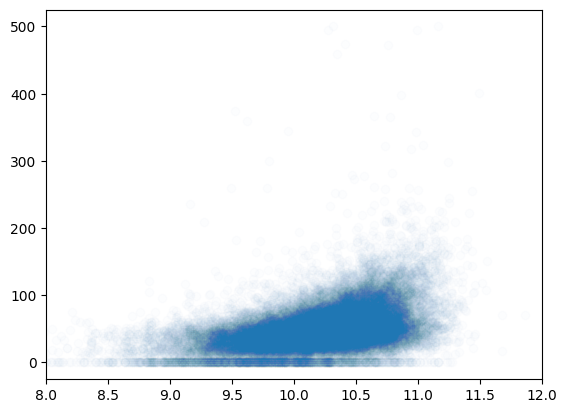

In [21]:
plt.scatter(dps_df['LOGM'], (dps_df['sigma_r']), alpha=0.01)
plt.xlim(left=8, right=12)
plt.show()

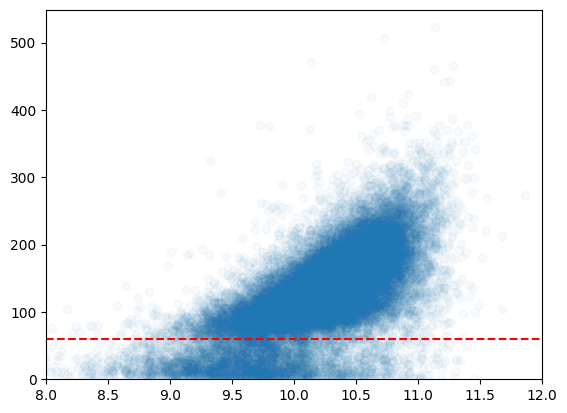

In [22]:
plt.scatter(dps_df['LOGM'], (dps_df['delta_dv']), alpha=0.03)
plt.axhline(60, color='r', linestyle='--')
plt.xlim(left=8, right=12)
plt.ylim(bottom=0)
plt.show()

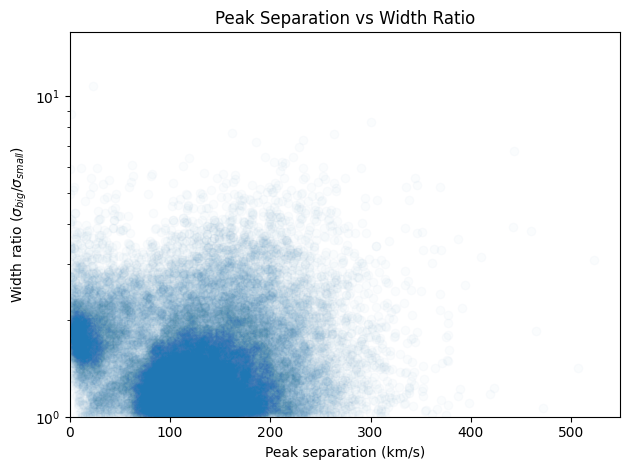

In [23]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], 10**np.abs(np.log10(dps_df['width_ratio'])), alpha=0.02)
# plt.plot(x, y, color='r', linestyle='--')
# plt.axvline(60, color='r', linestyle='--')
# plt.axhline(0.1, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
plt.title('Peak Separation vs Width Ratio')
plt.tight_layout()
# plt.savefig('./figures/Feb25/peak_sep_width_ratio.png')
plt.show()

In [24]:

# robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(~dps_df['incl'].isnull())&(dps_df['dp_count']>1)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())&(~robust_dps['flux_ratio'].isnull())]
robust_dps.sort_values(['width_ratio'], ascending=True).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
5744,39627758036322054,209.077072,-1.253912,0.247431,9.521063,1.103340,5.942606e-33,-1.362715e+00,373.505676,30.938263,...,5,REX,1.000000,0.370823,376.290009,0.000000,1.362715,0.113711,2.648615,SF+COMP
6643,39627763660882868,184.294128,-0.972807,0.188709,10.269643,-0.257766,1.586363e+02,-7.442450e+01,495.164734,60.390194,...,17,DEV,4.000000,0.977100,150.339996,35.666496,233.060806,0.136583,0.976677,SF+AGN
17311,39627794396741730,216.252991,0.233792,0.322136,11.051679,1.321636,2.198711e+01,-1.250719e+02,158.526352,8.678167,...,32,SER,3.216498,2.833057,102.769997,21.524508,147.059052,0.179990,1.097063,double AGN
22070,39627812264477753,201.302582,1.052723,0.304811,10.965445,1.524045,5.376753e+01,-1.509082e+02,195.648865,23.860506,...,17,SER,1.457420,1.032252,367.070007,55.000683,204.675720,0.186131,0.798170,SF+AGN
20706,39627806434396707,213.866089,0.863446,0.125449,10.989308,-10.698802,1.026853e+02,-1.114999e-11,494.225647,86.394539,...,20,SER,1.385490,2.159973,100.760002,68.795170,102.685303,0.186339,0.978610,COMP+AGN


In [25]:
print(len(robust_dps))

12430


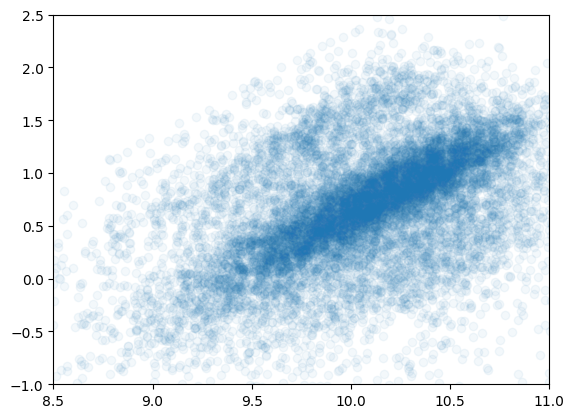

In [26]:
x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05)
plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
# plt.plot(x, y+0.6, color='r', linestyle='--', label='MS: LOGSFR = -9 + 0.9 * LOGM')
# plt.plot(x, y+0.9, color='r', linestyle=':')
# plt.plot(x, y+0.3, color='r', linestyle=':')
# plt.plot(x, y+1.2, color='gray', linestyle='--')
# plt.legend()
plt.show()

In [27]:
logm_bin_bound = np.linspace(8.5, 11, 7, endpoint=True)
logsfr_bin_bound = np.linspace(-1, 2.5, 7, endpoint=True)

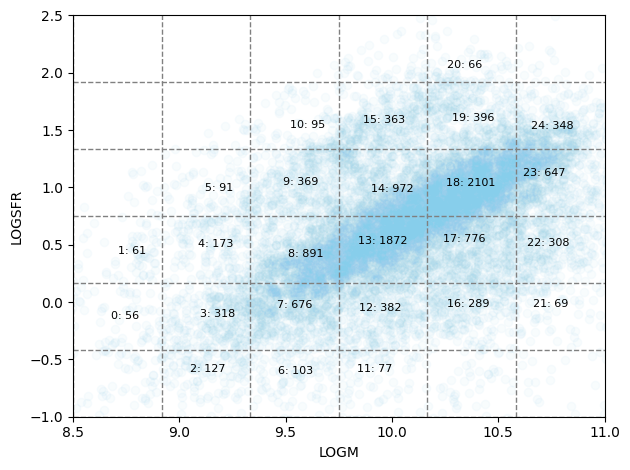

In [28]:

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05, color='skyblue')
for i in range(len(logm_bin_bound)-1):
    plt.axvline(logm_bin_bound[i], color='gray', linestyle='--', linewidth=1)
for j in range(len(logsfr_bin_bound)-1):
    plt.axhline(logsfr_bin_bound[j], color='gray', linestyle='--', linewidth=1)

bin_num = 0
bin_dps_list = []
for i in range(len(logm_bin_bound)-1):
    for j in range(len(logsfr_bin_bound)-1):
        bin_dps = robust_dps[(robust_dps['LOGM']>=logm_bin_bound[i]) & (robust_dps['LOGM']<logm_bin_bound[i+1]) & (robust_dps['LOGSFR']>=logsfr_bin_bound[j]) & (robust_dps['LOGSFR']<logsfr_bin_bound[j+1])]
        # print(f'Bin LOGM: [{logm_bin_bound[i]:.2f}, {logm_bin_bound[i+1]:.2f}), LOGSFR: [{logsfr_bin_bound[j]:.2f}, {logsfr_bin_bound[j+1]:.2f}), Count: {len(bin_dps)}')
        # plt.scatter(bin_dps['LOGM'], bin_dps['LOGSFR'], alpha=0.1, color='skyblue')
        if len(bin_dps)>50:
            bin_dps_list.append(bin_dps)
            plt.text(bin_dps['LOGM'].mean(), bin_dps['LOGSFR'].mean(), f'{bin_num}: {len(bin_dps)}', fontsize=8, ha='center')
            bin_num += 1

plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')
plt.tight_layout()
# plt.savefig('./figures/Feb25/logm_logsfr_bins.png')
plt.show()

In [29]:
logm_group = [[0, 1, 2, 3], [4, 5, 6, 7, 8], [9, 10, 11, 12, 13], [14, 15, 16, 17, 18], [19, 20, 21]]
logm_bin = [9, 9.5, 10, 10.5, 11]

logsfr_group = [[0, 4, 9], [1, 5, 10, 14], [2, 6, 11, 15, 19], [3, 7, 12, 16, 20], [8, 13, 17, 21], [18]]
logsfr_bin = [-0.5, 0.0, 0.5, 1.0, 1.5, 2]

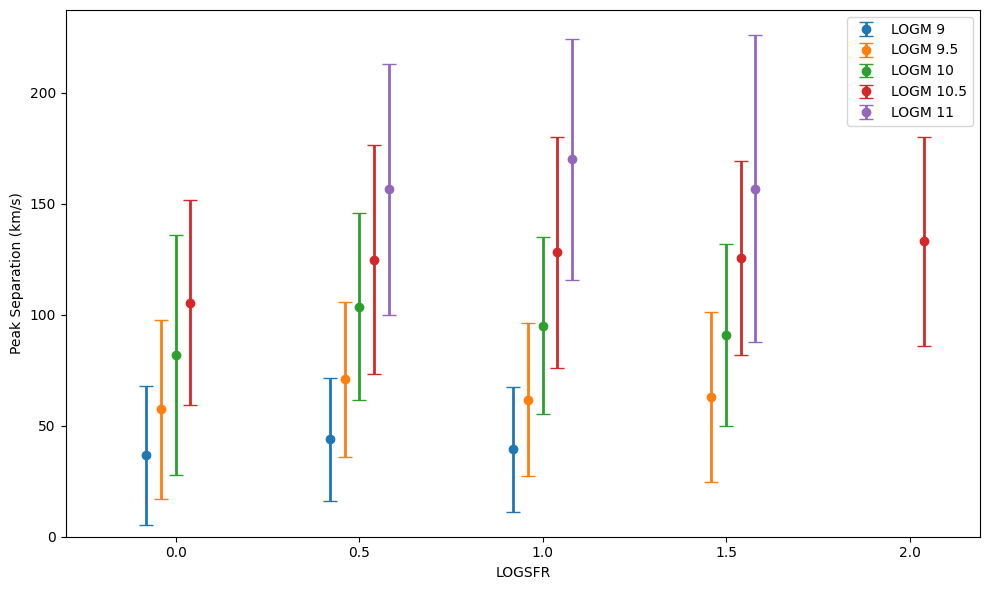

In [30]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
offsets = np.arange(-0.08, 0.12, 0.04)
plt.figure(figsize=(10, 6))
for i, subgroup in enumerate(logm_group):
    plt.errorbar(-1, -1, yerr=0, color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2, label=f'LOGM {logm_bin[i]}')
    # plt.scatter(-1, -1, color=colors[i], label=f'LOGM {logm_bin[i]}')
    for bin_idx in subgroup:
        bin_dps = bin_dps_list[bin_idx]
        for j in range(len(logsfr_group)):
            if bin_idx in logsfr_group[j]:
                # plt.scatter(logsfr_bin[j], bin_dps['delta_dv'].mean(), color=colors[i])
                plt.errorbar(logsfr_bin[j] + offsets[i], bin_dps['delta_dv'].mean(), yerr=bin_dps['delta_dv'].std(), color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2)
plt.ylim(bottom=0)
plt.xlim(left=-0.3)
plt.xlabel('LOGSFR')
plt.ylabel('Peak Separation (km/s)')
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/logm_sep.png')
plt.show()

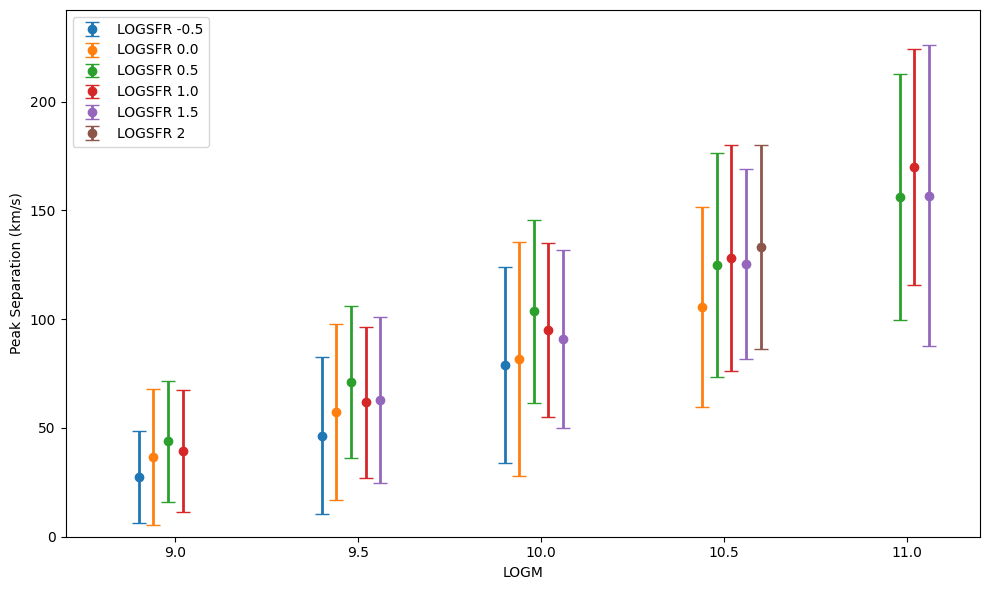

In [31]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
offsets = np.arange(-0.1, 0.11, 0.04)
plt.figure(figsize=(10, 6))
for i, subgroup in enumerate(logsfr_group):
    plt.errorbar(0, -100, yerr=0, color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2, label=f'LOGSFR {logsfr_bin[i]}')
    for bin_idx in subgroup:
        bin_dps = bin_dps_list[bin_idx]
        for j in range(len(logm_group)):
            if bin_idx in logm_group[j]:
                # plt.scatter(logm_bin[j], bin_dps['delta_dv'].mean(), color=colors[i], s=50)
                plt.errorbar(logm_bin[j] + offsets[i], bin_dps['delta_dv'].mean(), yerr=bin_dps['delta_dv'].std(), color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2)

# x = np.linspace(9, 11, 100)
# y = 55*(x-9)+55
# plt.plot(x, y, color='black', lw=2)
plt.xlabel('LOGM')
plt.ylabel('Peak Separation (km/s)')
plt.xlim(left=8.7, right=11.2)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/logsfr_sep.png')
plt.show()

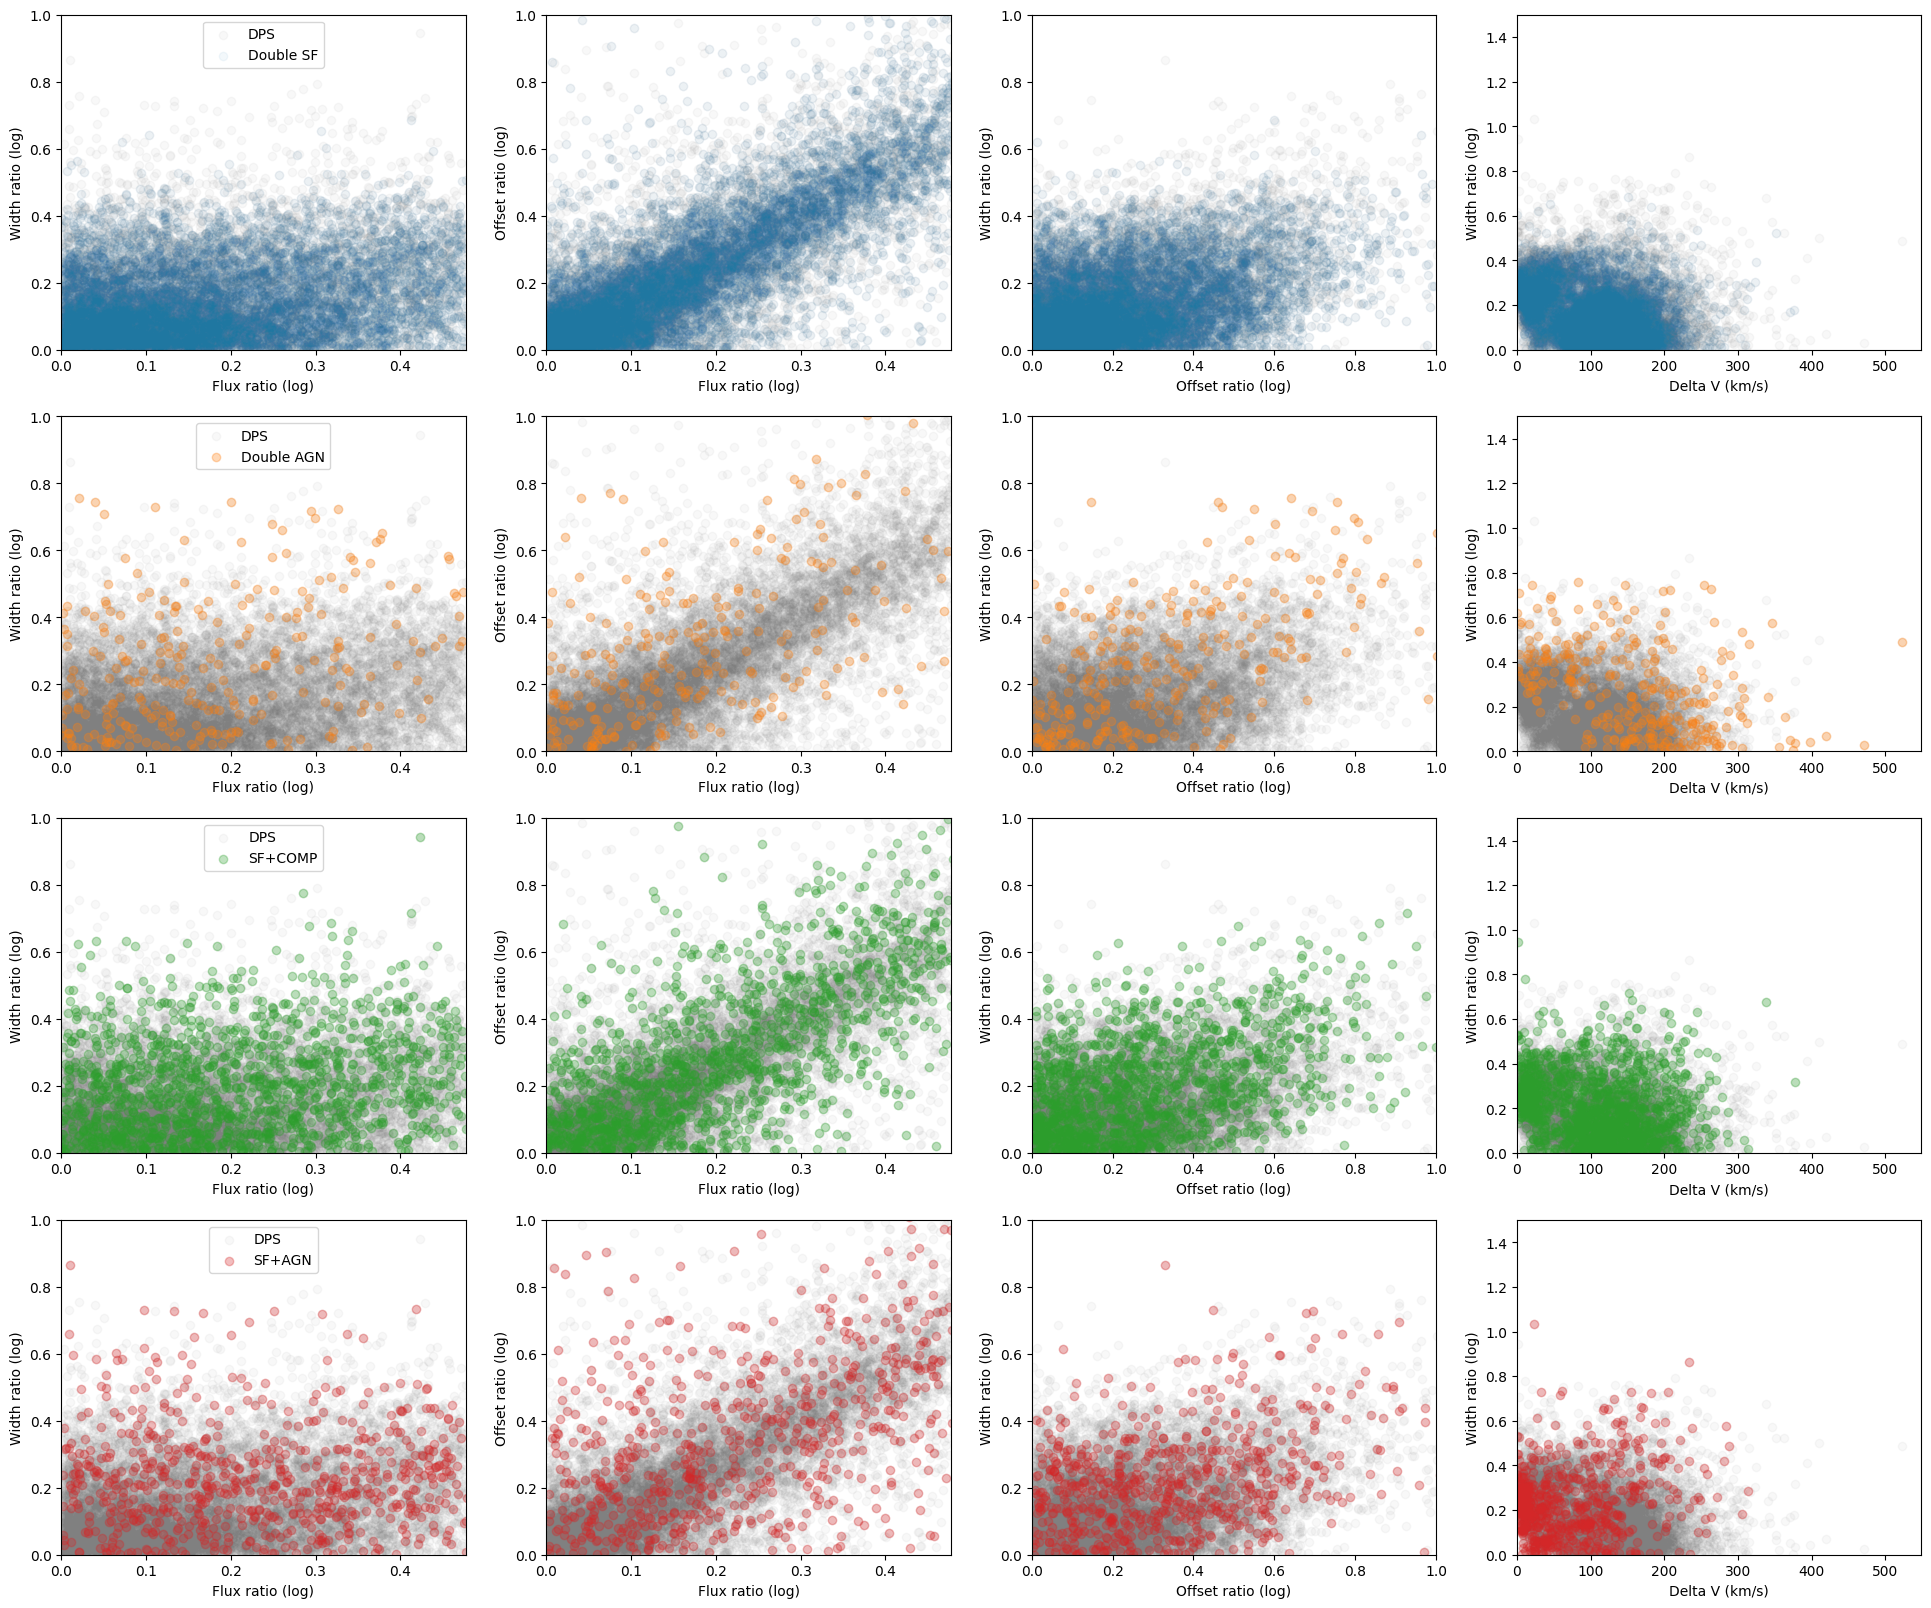

In [32]:

dSF = robust_dps[robust_dps['BPT_class_str']=='double SF'].copy()
dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN'].copy()
SF_COMP = robust_dps[robust_dps['BPT_class_str']=='SF+COMP'].copy()
SF_AGN = robust_dps[robust_dps['BPT_class_str']=='SF+AGN'].copy()

fig, axes = plt.subplots(4, 4, figsize=(24, 20))

labels = ['Double SF', 'Double AGN', 'SF+COMP', 'SF+AGN']
colors = ['C0', 'C1', 'C2', 'C3']
for i, subset in enumerate([dSF, dAGN, SF_COMP, SF_AGN]):
    ax = axes[i]
    ax[0].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(robust_dps['width_ratio'])), alpha=.05, color='gray', label='DPS')
    ax[0].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(subset['width_ratio'])), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[0].set_xlim(left=0, right=np.log10(3))
    ax[0].set_ylim(bottom=0, top=np.log10(10))
    ax[0].set_xlabel('Flux ratio (log)')
    ax[0].set_ylabel('Width ratio (log)')
    ax[0].legend()


    ax[1].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(-robust_dps['dv_l']/(robust_dps['dv_r']))), alpha=.05, color='gray', label='DPS')
    ax[1].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(-subset['dv_l']/(subset['dv_r']))), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[1].set_ylim(bottom=0, top=1)
    ax[1].set_xlim(left=0, right=np.log10(3))
    ax[1].set_xlabel('Flux ratio (log)')
    ax[1].set_ylabel('Offset ratio (log)')

    ax[2].scatter(np.abs(np.log10(-robust_dps['dv_l']/(robust_dps['dv_r']))), np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[2].scatter(np.abs(np.log10(-subset['dv_l']/(subset['dv_r']))), np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[2].set_xlim(left=0, right=1)
    ax[2].set_ylim(bottom=0, top=1)
    ax[2].set_xlabel('Offset ratio (log)')
    ax[2].set_ylabel('Width ratio (log)')
    
    ax[3].scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[3].scatter(subset['delta_dv'], np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[3].set_xlim(left=0)
    ax[3].set_ylim(bottom=0, top=1.5)
    ax[3].set_xlabel('Delta V (km/s)')
    ax[3].set_ylabel('Width ratio (log)')


plt.show()




In [33]:
merger_cand = robust_dps[((robust_dps['width_ratio']<1/3)|(robust_dps['width_ratio']>3))].copy()
merger_cand_b = merger_cand[(merger_cand['width_ratio']>3)&(merger_cand['sigma_l']<250)&(merger_cand['sigma_r']>1)].copy()
merger_cand_r = merger_cand[(merger_cand['width_ratio']<1/3)&(merger_cand['sigma_r']<250)&(merger_cand['sigma_l']>1)].copy()
merger_cand = pd.concat([merger_cand_b, merger_cand_r])
merger_cand.sort_values(['width_ratio'], ascending=False).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
24841,39627823970780277,179.054306,1.431388,0.332877,10.820004,1.507084,1.899154e+02,-24.734438,11.509830,182.372482,...,65,SER,0.797546,1.127784,114.199997,51.671078,214.649872,6.203485,2.004067,SF+LINER
23944,39627818316858830,202.075577,1.366346,0.079271,9.774653,-0.263470,8.334392e-10,-11.523685,14.042244,216.877518,...,5,REX,1.000000,1.926894,17.260000,0.000000,11.523685,5.989530,0.518630,SF+COMP
24134,39627818392356897,206.583344,1.331737,0.315747,10.412442,0.004569,1.205123e+02,-13.156992,27.130077,222.601425,...,20,REX,1.000000,0.444960,43.939999,0.000000,133.669266,5.778536,1.866795,COMP+AGN
20701,39627806430204923,213.743362,0.855273,0.318180,10.465372,1.259652,1.465246e+02,-18.083614,16.211184,174.945343,...,20,REX,1.000000,0.369185,149.440002,0.000000,164.608261,5.516504,1.356616,COMP+AGN
19437,39627805851389902,179.199615,0.843170,0.235508,10.467430,1.479001,1.293736e+02,-26.106329,13.081861,170.639618,...,17,SER,1.100929,1.478815,117.050003,37.498905,155.479904,5.355939,1.359014,SF+AGN


In [34]:
# for i, id in enumerate(merger_cand.sort_values(['width_ratio'], ascending=False).head(10)['TARGETID'].to_list()):
#     df = merger_cand[merger_cand['TARGETID'] == id]
#     print(df['BPT_class_str'])
#     print(image_link(df['RA'].iloc[0], df['DEC'].iloc[0], plot=True, save_image=True, fname=f"./images/{id}_image.jpg"))

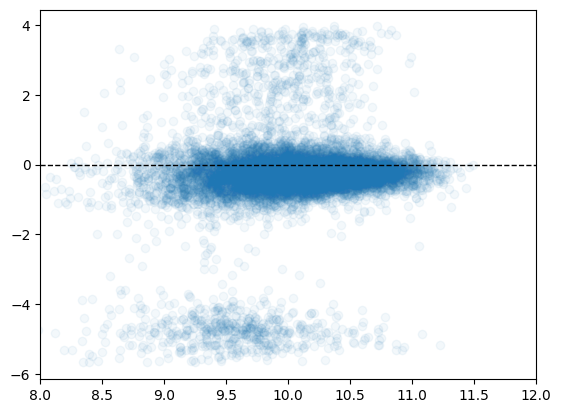

In [35]:
plt.scatter(robust_dps['LOGM'], np.log10(robust_dps['sigma_l']/robust_dps['VD_SL']), alpha=0.05)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlim(left=8, right=12)
plt.show()

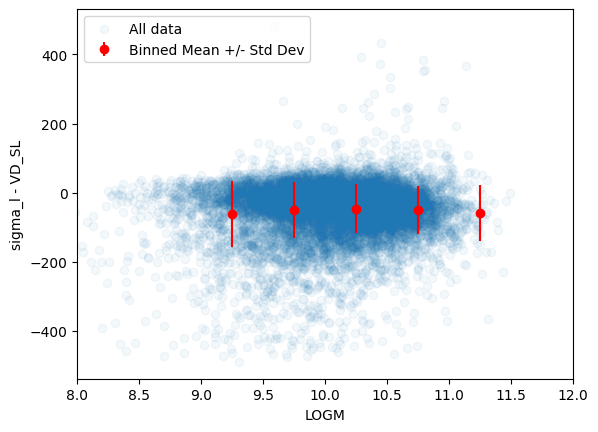

In [36]:
from scipy.stats import binned_statistic

# Bin the data by 'LOGM'
bin_means, bin_edges, binnumber = binned_statistic(robust_dps['LOGM'],
                                                   robust_dps['sigma_l'] - robust_dps['VD_SL'],
                                                   statistic='mean',
                                                   bins=5, range=(9, 11.5))
bin_stds, _, _ = binned_statistic(robust_dps['LOGM'],
                                  robust_dps['sigma_l'] - robust_dps['VD_SL'],
                                  statistic='std',
                                  bins=5, range=(9, 11.5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create the plot
# plt.figure(figsize=(8, 6))
# Plot the original scatter data
plt.scatter(robust_dps['LOGM'], robust_dps['sigma_l'] - robust_dps['VD_SL'], alpha=0.05, label='All data')
# Plot the binned means with error bars
plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', color='r', label='Binned Mean +/- Std Dev')

# Set plot labels and limits
plt.xlabel('LOGM')
plt.ylabel('sigma_l - VD_SL')
plt.xlim(left=8, right=12)
plt.legend()
plt.show()

In [37]:
robust_dps.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'dv_r', 'dv_l',
       'sigma_r', 'sigma_l', 'sigma_1comp', 'p_value', 'OII3726_1comp',
       'OII3729_1comp', 'Hbeta_1comp', 'OIII4959_1comp', 'OIII5007_1comp',
       'NII6548_1comp', 'Halpha_1comp', 'NII6583_1comp', 'SII6716_1comp',
       'SII6731_1comp', 'OII3726_2compL', 'OII3729_2compL', 'Hbeta_2compL',
       'OIII4959_2compL', 'OIII5007_2compL', 'NII6548_2compL', 'Halpha_2compL',
       'NII6583_2compL', 'SII6716_2compL', 'SII6731_2compL', 'OII3726_2compR',
       'OII3729_2compR', 'Hbeta_2compR', 'OIII4959_2compR', 'OIII5007_2compR',
       'NII6548_2compR', 'Halpha_2compR', 'NII6583_2compR', 'SII6716_2compR',
       'SII6731_2compR', 'OII3726_dp', 'OII3729_dp', 'Hbeta_dp', 'OIII4959_dp',
       'OIII5007_dp', 'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 'SII6716_dp',
       'SII6731_dp', 'OII3726_noise_b', 'OII3729_noise_b', 'Hbeta_noise_b',
       'OIII4959_noise_b', 'OIII5007_noise_b', 'NII6548_noise_b',
       'Halpha_no

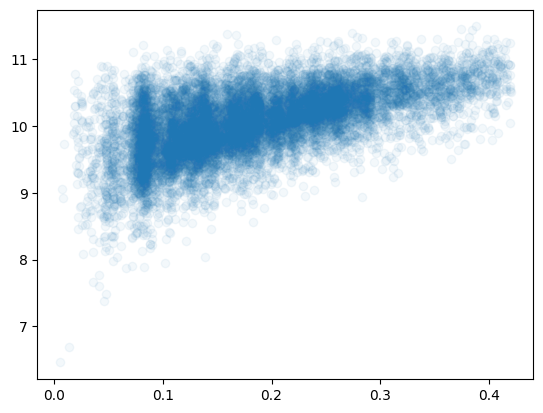

In [38]:
plt.scatter(robust_dps['Z'], robust_dps['LOGM'], alpha=0.05)
plt.show()

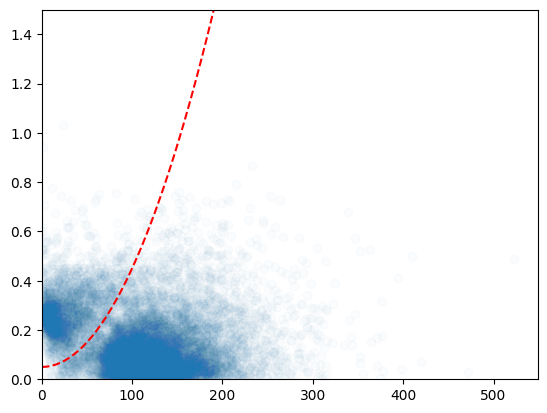

In [39]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.02)
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.show()

In [40]:
cake_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 < np.abs(np.log10(robust_dps['width_ratio']))].copy()
horn_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 > np.abs(np.log10(robust_dps['width_ratio']))].copy()

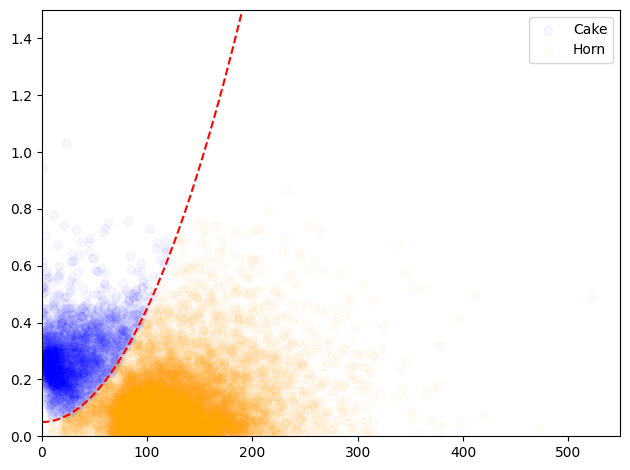

In [41]:
plt.scatter(cake_dps['delta_dv'], np.abs(np.log10(cake_dps['width_ratio'])), alpha=0.03, color='blue', label='Cake')
plt.scatter(horn_dps['delta_dv'], np.abs(np.log10(horn_dps['width_ratio'])), alpha=0.03, color='orange', label='Horn')
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/cake_horn.png')
plt.show()

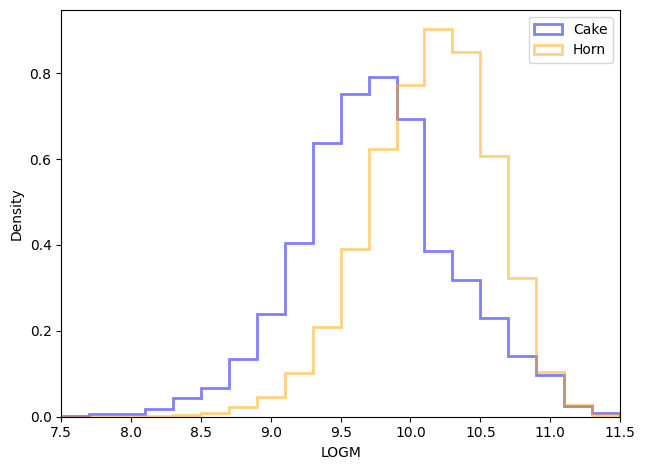

In [43]:
plt.hist(cake_dps['LOGM'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(7.5, 11.5))
plt.hist(horn_dps['LOGM'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(7.5, 11.5))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=7.5, right=11.5)
# plt.savefig('./figures/Feb25/cake_horn_logm.png')
plt.show()

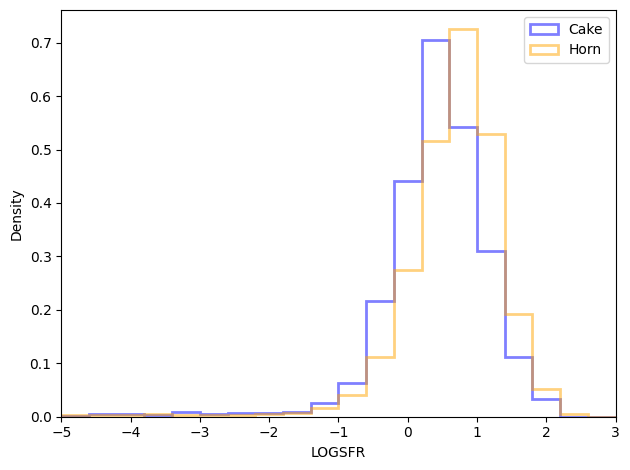

In [44]:
plt.hist(cake_dps['LOGSFR'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(-5, 3))
plt.hist(horn_dps['LOGSFR'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(-5, 3))
plt.xlabel('LOGSFR')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=-5, right=3)
plt.tight_layout()
# plt.savefig('./figures/Feb25/cake_horn_logsfr.png')
plt.show()

In [45]:
print(cake_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(cake_dps))

BPT_class_str
double SF         64.296296
SF+COMP           15.333333
SF+AGN            12.148148
double AGN         2.925926
COMP+AGN           2.740741
double COMP        1.777778
AGN+uncertain      0.185185
AGN+LINER          0.185185
COMP+LINER         0.148148
SF+LINER           0.111111
COMP+uncertain     0.074074
SF+uncertain       0.074074
Name: proportion, dtype: float64
2700


In [46]:
print(horn_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(horn_dps))

BPT_class_str
double SF         75.303186
SF+COMP           11.336074
SF+AGN             3.833505
double COMP        3.792395
COMP+AGN           2.826310
double AGN         2.261048
AGN+LINER          0.277492
COMP+LINER         0.184995
SF+LINER           0.102775
COMP+uncertain     0.041110
AGN+uncertain      0.030832
double LINER       0.010277
Name: proportion, dtype: float64
9730


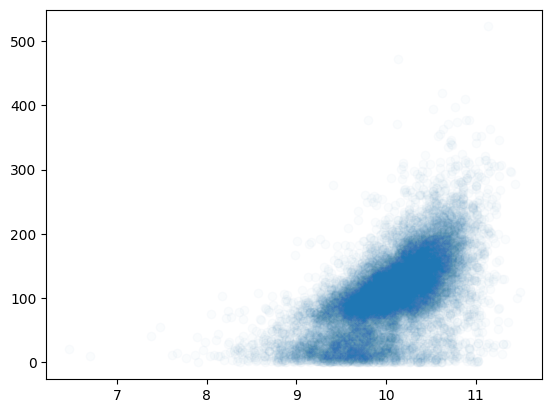

In [47]:
plt.scatter(robust_dps['LOGM'], robust_dps['delta_dv'], alpha=0.02)
# x = np.linspace(8, 11.5, 100)
# y = 55*(x-9)+55
# plt.plot(x, y, color='black', lw=2)
plt.show()

In [48]:
len(merger_cand)

212

In [49]:
merger_cand.sort_values(by='SHAPE_R', ascending=True).head(30)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
12617,39627781868359233,189.667679,-0.128895,0.204595,9.150351,1.288560,3.605014e+01,-20.082802,52.315506,187.699219,...,8,REX,1.000000,0.252451,462.040009,0.000000,56.132942,3.144204,1.175733e+00,double COMP
12245,39627781725753388,181.210297,-0.199903,0.119530,9.546997,0.146538,4.166625e+00,-12.662981,39.003746,156.730759,...,32,REX,1.000000,0.306086,72.820000,0.000000,16.829605,3.148004,4.090945e-01,double AGN
10201,39627775648208586,178.990906,-0.403864,0.250296,10.410080,-0.460224,1.907843e+01,-120.865959,113.949112,17.914629,...,32,REX,1.000000,0.363201,86.470001,0.000000,139.944397,0.291364,4.496492e-01,double AGN
20701,39627806430204923,213.743362,0.855273,0.318180,10.465372,1.259652,1.465246e+02,-18.083614,16.211184,174.945343,...,20,REX,1.000000,0.369185,149.440002,0.000000,164.608261,5.516504,1.356616e+00,COMP+AGN
8573,39627769738430225,186.589813,-0.781932,0.284080,10.399223,1.589749,1.180609e+02,-17.696682,25.473671,123.629662,...,5,REX,1.000000,0.375545,146.039993,0.000000,135.757553,3.321926,1.612439e+00,SF+COMP
5758,39627758040519923,209.470810,-1.319891,0.409494,10.987538,2.041643,1.081574e+02,-20.078102,37.206657,181.103363,...,5,REX,1.000000,0.392231,82.769997,0.000000,128.235474,4.034580,1.794181e+00,SF+COMP
18594,39627800235214582,204.327087,0.621960,0.276975,10.449203,1.105227,5.672235e+01,-86.754570,130.683807,29.761446,...,5,REX,1.000000,0.400948,176.509995,0.000000,143.476913,0.308590,1.506428e+00,SF+COMP
6584,39627763639911175,183.029068,-1.072288,0.113915,9.275297,1.141646,6.485963e+01,-40.023403,208.526596,59.595619,...,8,REX,1.000000,0.438636,124.989998,0.000000,104.883026,0.322254,1.415944e+00,double COMP
24134,39627818392356897,206.583344,1.331737,0.315747,10.412442,0.004569,1.205123e+02,-13.156992,27.130077,222.601425,...,20,REX,1.000000,0.444960,43.939999,0.000000,133.669266,5.778536,1.866795e+00,COMP+AGN
15731,39627788457611299,222.424561,0.001545,0.112255,9.284292,1.317066,8.595424e+00,-50.544670,42.070316,182.314743,...,8,SER,5.140268,0.477854,138.279999,23.785040,59.140095,3.470759,3.691488e-01,double COMP


In [50]:
print(merger_cand['MORPHTYPE'].value_counts(normalize=True))

MORPHTYPE
SER    0.712264
REX    0.136792
DEV    0.108491
EXP    0.042453
Name: proportion, dtype: float64


In [51]:
merger_cand.sort_values(by='SERSIC', ascending=True).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
20058,39627806132409690,195.980347,0.649483,0.371827,10.268726,1.929244,3.098246e+01,-1.892368e+01,176.623322,32.574043,...,5,SER,0.500000,1.141954,187.059998,53.776978,4.990614e+01,0.235557,1.406165,SF+COMP
2838,39627751518374018,180.610947,-1.487653,0.150886,10.660643,-8.282505,1.924204e+01,-9.047920e+01,184.979843,22.922722,...,8,SER,0.500000,3.760101,472.760010,61.494495,1.097212e+02,0.208625,0.453930,double COMP
737,39627740042759487,216.649796,-1.998467,0.275597,10.619296,1.140777,6.071157e+00,-2.806637e+01,158.791992,30.949692,...,5,SER,0.500000,1.797086,83.599998,66.339720,3.413752e+01,0.261341,0.523581,SF+COMP
22299,39627812348362788,206.250107,1.015225,0.256164,10.143916,1.745900,4.790232e+00,-1.097637e+01,137.702667,26.461929,...,2,SER,0.519890,1.410205,145.600006,64.921470,1.576661e+01,0.279384,0.634154,double SF
3364,39627751757448774,194.821686,-1.573625,0.168504,10.665784,1.110838,6.071265e+01,-3.229084e+01,171.268936,47.474007,...,5,SER,0.535460,5.108536,154.229996,62.444730,9.300349e+01,0.326508,1.591683,SF+COMP
21635,39627812037988321,187.943954,0.981470,0.146044,10.290135,1.085277,1.172983e+02,-2.040419e+01,17.977121,106.842499,...,8,SER,0.567813,2.227698,109.349998,77.917490,1.377025e+02,3.046522,2.638704,double COMP
23804,39627818258140974,198.685837,1.363228,0.387003,10.232123,1.754935,1.964230e+01,-7.545430e+01,105.034401,18.720751,...,2,SER,0.585539,1.178145,173.759995,56.940475,9.509660e+01,0.298424,0.653341,double SF
9691,39627770195609133,213.817230,-0.687208,0.289668,10.538917,1.497841,4.264588e+01,-2.698650e+00,18.091877,148.479782,...,2,SER,0.595702,1.254058,146.250000,47.692234,4.534453e+01,4.497047,2.023785,double SF
8520,39627769717458009,185.297592,-0.786711,0.209338,10.576923,1.014431,1.948908e+02,-1.571261e+02,34.660255,149.947693,...,2,SER,0.614774,1.670016,397.320007,62.618950,3.520168e+02,3.326816,0.553915,double SF
16265,39627793914401399,187.744080,0.175818,0.308183,9.544332,1.400752,3.568757e+01,-1.466460e+02,47.088730,171.129578,...,2,SER,0.624204,2.219597,163.270004,56.258330,1.823336e+02,3.167145,0.399074,double SF


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_29310/1571214756.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=labels, fontsize=12)


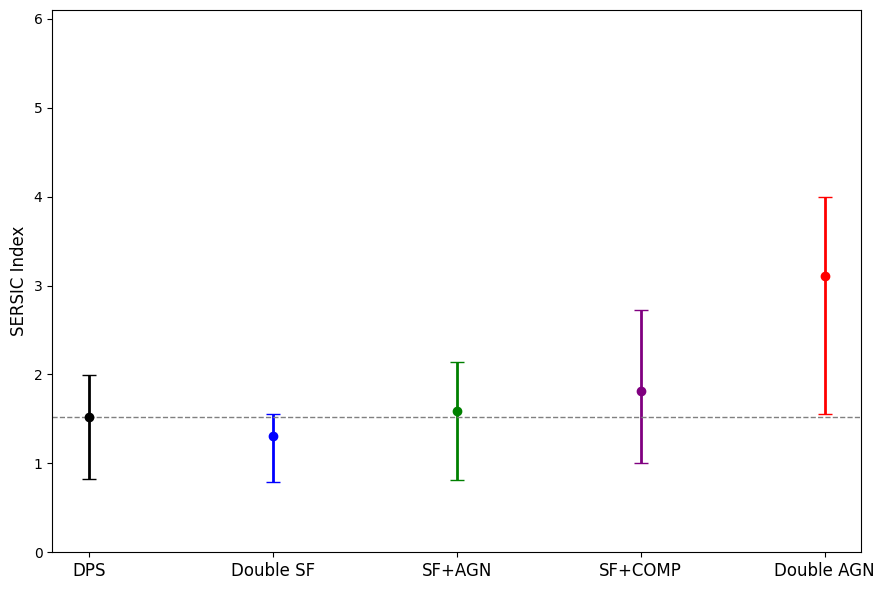

In [52]:
fig, ax = plt.subplots(figsize=(9, 6))

# Data to plot
datasets = [robust_dps, dSF, SF_AGN, SF_COMP, dAGN]
labels = ['DPS', 'Double SF', 'SF+AGN', 'SF+COMP', 'Double AGN']
colors = ['k', 'blue', 'green', 'purple', 'red']

# Calculate means and quantiles for SERSIC index
means = [df['SERSIC'].mean() for df in datasets]
q25 = [df['SERSIC'].quantile(0.2) for df in datasets]
q75 = [df['SERSIC'].quantile(0.8) for df in datasets]

# Calculate asymmetric errors
errors = [np.array([means[i] - q25[i], q75[i] - means[i]]).reshape(2, 1) for i in range(len(datasets))]

# Create the error bar plot
for i, df in enumerate(datasets):
    ax.errorbar(labels[i], means[i], yerr=errors[i], fmt='o', capsize=5, color=colors[i], ecolor=colors[i], elinewidth=2)

# Add some jittered scatter points for visualization
# for i, df in enumerate(datasets):
#     # Generate jitter for x-axis
#     jitter = np.random.normal(0, 0.05, size=len(df))
#     ax.scatter([i + j for j in jitter], df['SERSIC'], alpha=0.01, color=colors[i])
ax.axhline(means[0], color='gray', linestyle='--', linewidth=1)
ax.set_xticklabels(labels=labels, fontsize=12)
ax.set_ylabel('SERSIC Index', fontsize=12)
# ax.set_title('SERSIC Index Distribution by BPT Class', fontsize=14)
ax.set_ylim(bottom=0, top=6.1)
plt.tight_layout()
# plt.savefig('./figures/Feb25/SERSIC_by_BPT_class.png')
plt.show()

In [53]:
robust_dps[robust_dps['SERSIC']>4].head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_2comp,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
10,39627739388446113,177.554276,-1.971866,0.083630,10.489296,0.985447,7.153632e+01,-36.476711,34.187515,53.084030,...,5,SER,5.204151,1.424334,123.650002,46.709350,108.013031,1.309699,1.575454,SF+COMP
59,39627739422001687,179.589584,-1.983656,0.188073,10.676142,1.441621,1.535183e+02,-64.510414,51.693905,102.733109,...,80,SER,5.744121,1.003499,220.029999,33.157880,218.028687,1.782857,1.625299,AGN+LINER
127,39627739484919966,183.464890,-1.908738,0.241880,10.447141,1.031131,5.474606e+01,-46.558239,41.360008,50.869469,...,5,SER,6.000000,0.658322,62.230000,41.016933,101.304298,1.157781,1.178645,SF+COMP
146,39627739510081481,184.832153,-1.994655,0.131692,10.883685,0.435817,1.106218e+02,-78.526596,44.355080,95.646362,...,5,SER,5.224558,13.624000,140.080002,52.719150,189.148376,1.840113,0.762291,SF+COMP
238,39627739610743754,190.792465,-1.901006,0.118766,9.964684,0.618813,6.161938e+01,-51.635899,30.902929,45.498573,...,8,SER,6.000000,8.394822,80.150002,54.387154,113.255280,1.245658,0.997146,double COMP
308,39627739661078029,193.907593,-1.994841,0.210115,10.571492,1.220360,9.859166e+00,-189.904358,73.689636,329.490021,...,20,SER,6.000000,0.572496,191.630005,23.622742,199.763519,4.154865,0.367165,COMP+AGN
313,39627739673657999,194.528000,-1.879498,0.288526,11.018009,1.502870,1.164168e+02,-133.355270,74.848251,85.970703,...,2,SER,4.392308,1.810741,121.580002,36.186390,249.772095,1.131024,0.792888,double SF
415,39627739753351383,199.346436,-1.955179,0.106683,10.994400,0.165413,9.268068e+01,-71.480705,59.235680,74.402168,...,2,SER,6.000000,8.665271,135.089996,62.175020,164.161377,1.200308,1.098674,double SF
468,39627739791100690,201.636734,-1.883813,0.183866,10.717326,0.258424,1.152866e+01,-63.794189,128.038300,203.230988,...,272,SER,4.514649,0.878542,141.009995,26.912275,75.322845,1.560768,0.217245,AGN+uncertain
473,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,2.033923e+02,-194.856537,162.299377,146.382141,...,32,SER,6.000000,1.987401,205.649994,60.036884,398.248840,0.905549,1.131461,double AGN


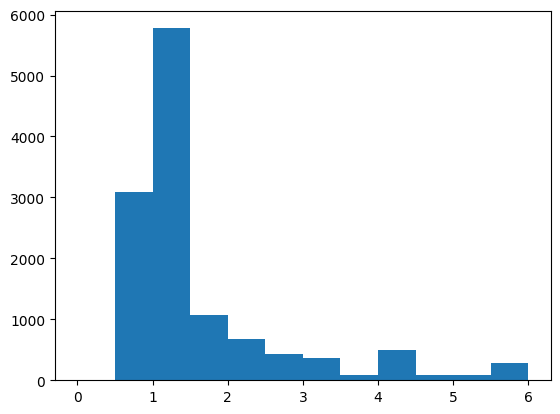

In [54]:
plt.hist(robust_dps['SERSIC'], align='mid', bins=12)
plt.show()

In [55]:
# dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN']
# print(len(dAGN))
# for i in range(len(dAGN)):
#     ra, dec = dAGN.iloc[i][['RA', 'DEC']]
#     r = dAGN.iloc[i]['SHAPE_R']
#     if r < 1:
#         image_link(ra, dec, side_arcmin=0.3, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")
#     else:
#         image_link(ra, dec, side_arcmin=0.5/3*r, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")

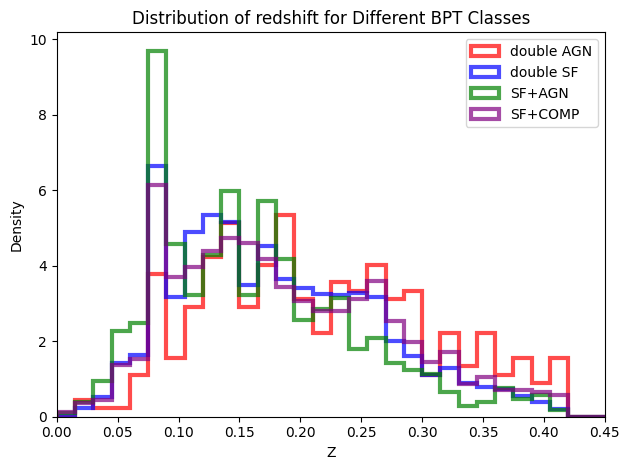

In [56]:
# plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3)
plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3)
plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3)
plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3)
plt.xlim((0, 0.45))
plt.xlabel('Z')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of redshift for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/redshift_distribution.png')
plt.show()

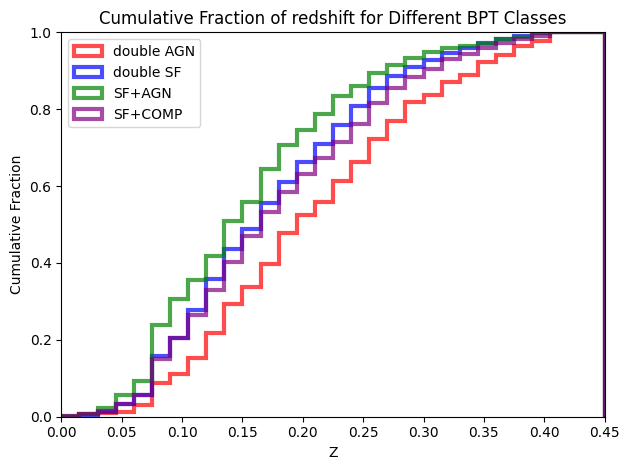

In [57]:
# plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=False, linewidth=3)
plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.xlim((0, 0.45))
plt.ylim((0, 1))
plt.xlabel('Z')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.title('Cumulative Fraction of redshift for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/redshift_cumulative_distribution.png')
plt.show()

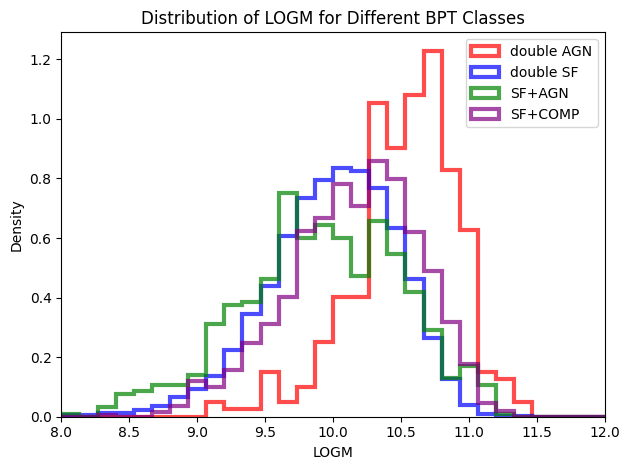

In [58]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3)
plt.xlim((8, 12))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of LOGM for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/logm_distribution.png')
plt.show()

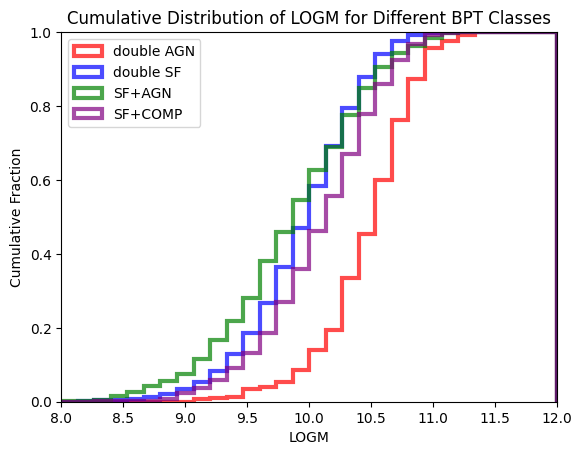

In [59]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.xlim((8, 12))
plt.ylim((0, 1))
plt.xlabel('LOGM')
plt.ylabel('Cumulative Fraction')
plt.title('Cumulative Distribution of LOGM for Different BPT Classes')
plt.legend()
# plt.savefig('./figures/Feb25/logm_cumulative_distribution.png')
plt.show()

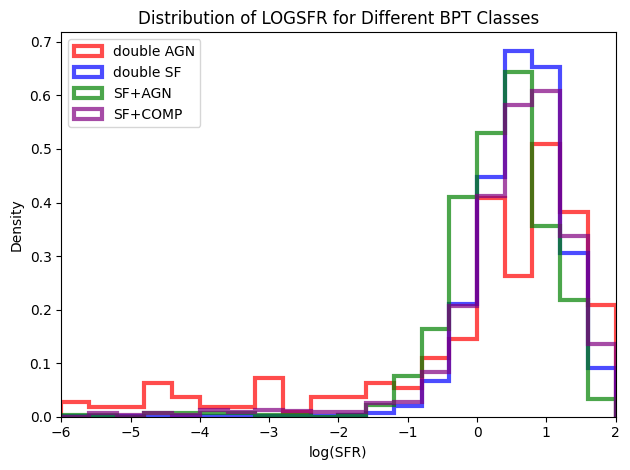

In [60]:
plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3)
plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3)
plt.xlim((-6, 2))
plt.xlabel('log(SFR)')
plt.ylabel('Density')
plt.title('Distribution of LOGSFR for Different BPT Classes')
plt.legend()
plt.tight_layout()
# plt.savefig('./figures/Feb25/logsfr_distribution.png')
plt.show()

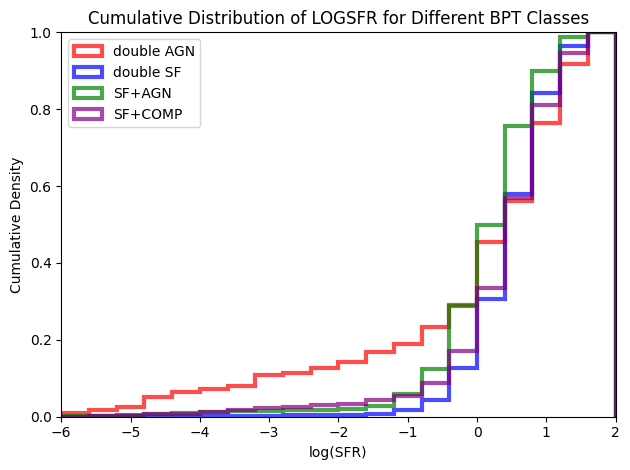

In [61]:
plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.xlim((-6, 2))
plt.ylim((0, 1))
plt.xlabel('log(SFR)')
plt.ylabel('Cumulative Density')
plt.legend()
plt.title('Cumulative Distribution of LOGSFR for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/logsfr_cumulative_distribution.png')
plt.show()

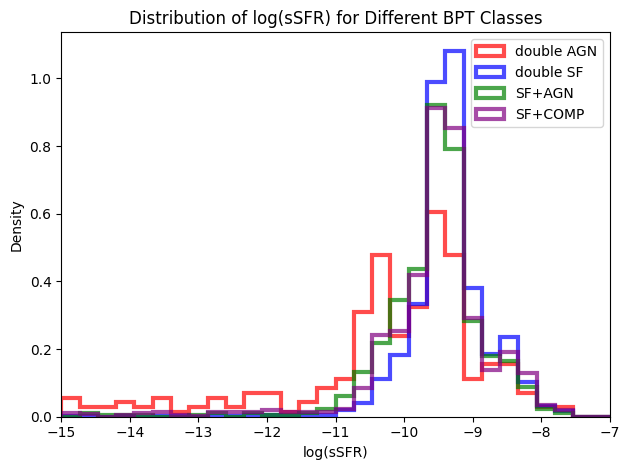

In [62]:
plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3)
plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3)
plt.xlim((-15, -7))
plt.xlabel('log(sSFR)')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of log(sSFR) for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/logssfr_distribution.png')
plt.show()

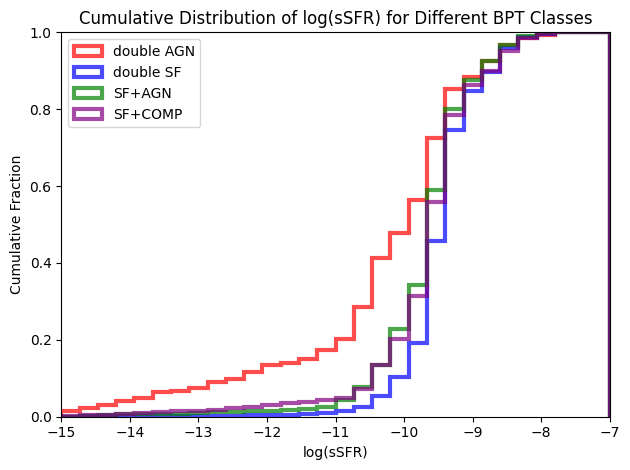

In [63]:
plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.xlim((-15, -7))
plt.ylim((0, 1))
plt.xlabel('log(sSFR)')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.title('Cumulative Distribution of log(sSFR) for Different BPT Classes')
plt.tight_layout()
# plt.savefig('./figures/Feb25/logssfr_cumulative_distribution.png')
plt.show()

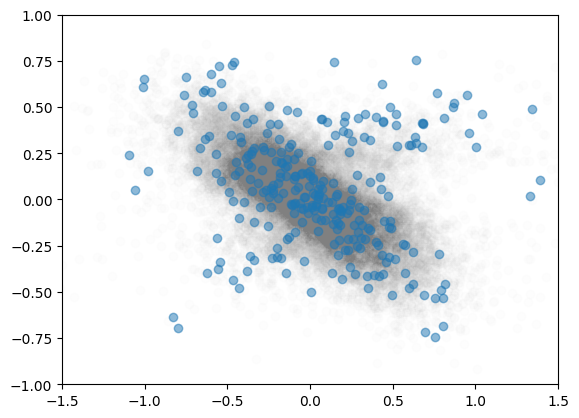

In [64]:
Mr_Ml_ratio = np.log10(-dAGN['dv_l']/dAGN['dv_r'])
plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01, color='gray')
plt.scatter((Mr_Ml_ratio), (np.log10(dAGN['width_ratio'])), alpha=0.5)
plt.xlim((-1.5, 1.5))
plt.ylim((-1, 1))
plt.show()